K-Fold Accuracy Scores:
[0.80446927 0.80898876 0.80898876 0.81460674 0.83146067]
Mean Accuracy: 0.8137028435126483


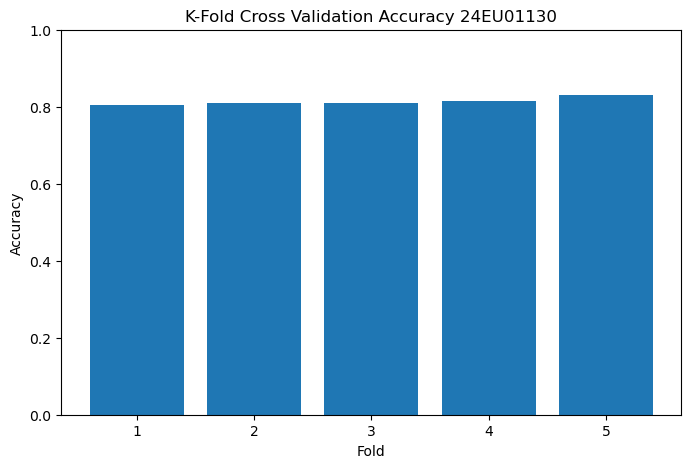

Best Parameters:
{'max_depth': 10, 'n_estimators': 150}
Best Grid Search Accuracy:
0.833927562613772


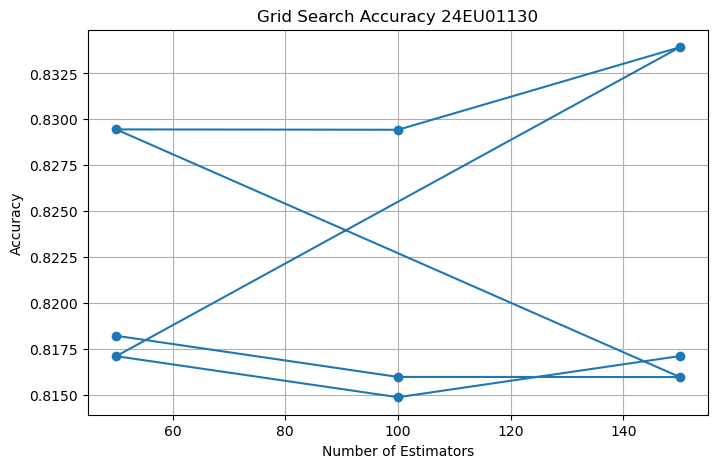

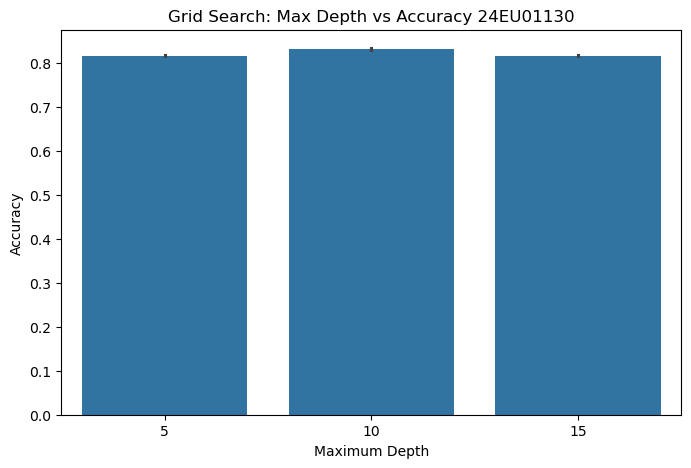

In [8]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

df = sns.load_dataset("titanic")

df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']]

df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

X = df.drop('survived', axis=1)
y = df['survived']

model = RandomForestClassifier(random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

print("K-Fold Accuracy Scores:")
print(scores)
print("Mean Accuracy:", scores.mean())

plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), scores)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("K-Fold Cross Validation Accuracy 24EU01130")
plt.ylim(0, 1)
plt.show()

parameters = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    parameters,
    cv=5,
    scoring='accuracy'
)

grid.fit(X, y)

print("Best Parameters:")
print(grid.best_params_)

print("Best Grid Search Accuracy:")
print(grid.best_score_)

results = pd.DataFrame(grid.cv_results_)

plt.figure(figsize=(8, 5))
plt.plot(
    results['param_n_estimators'].astype(int),
    results['mean_test_score'],
    'o-'
)
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("Grid Search Accuracy 24EU01130")
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x='param_max_depth', y='mean_test_score', data=results)
plt.xlabel("Maximum Depth")
plt.ylabel("Accuracy")
plt.title("Grid Search: Max Depth vs Accuracy 24EU01130")
plt.show()